## 04.P Geospatial Data Problem Set – Summarizing Airborne Snow Observatory Data

__Background:__ For your graduate research, you are using lidar-derived snow water equivalent (SWE) estimates to assimilate into a physics based hydrology model to make streamflow predictions. In thinking through your hypotheses portions of the landscape where SWE data will have the most impact, you are reminded of a figure you saw in a presentation at a recent meeting. The figure shows how the distribution of SWE and land area across a range of elevation interact to control the distribution of water storage in the landscape. The figure looked like the following:

<img src='../img/aso_swe.png' alt='Upper Colorado ASO Analysis' width='750' style='display: block; margin: 0 auto'/>

You already have grids of estimated SWE from the Airborne Snow Observatory (ASO) for 4 separate dates at a 50 m spatial resolution, and a coregistered digital elevation model of the study area – the East River in the Colorado Rocky Mountains.  

__Task:__ Use the skills you've developed and the example notebooks you've examined in this module to create an image like the above. The ASO and coregistered DEM can be found in [this Google Drive folder](https://drive.google.com/drive/u/0/folders/1SkjOWPPJe5N25arCW6qbf2ZJWQsrUAAp). Use any of the four ASO files, which corresponds to 2 different dates in 2018 or 2019, or write your code generically to plot any or all dates. You should only need `rasterio`, `numpy`, and `matplotlib` to create this figure.    

In [2]:
import numpy as np
import rasterio as rio
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

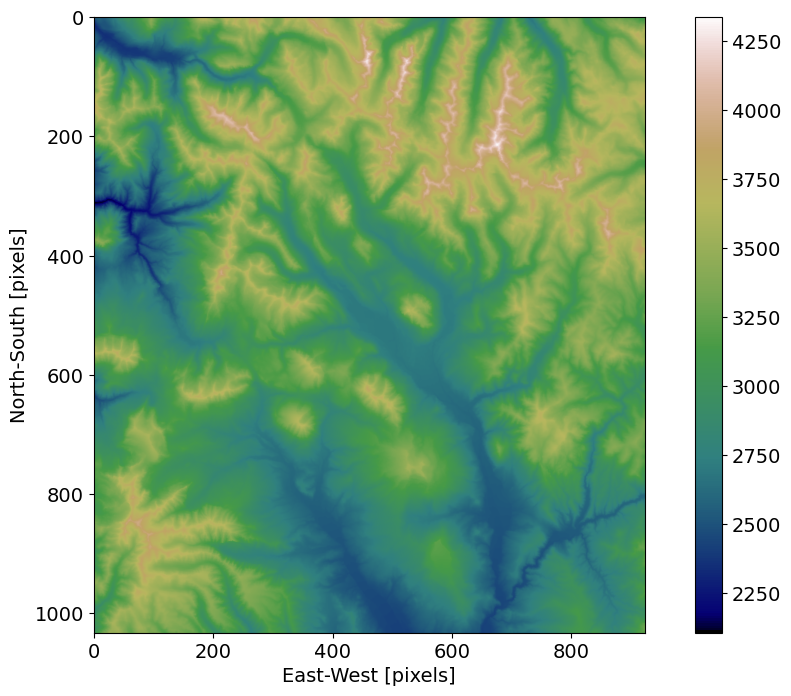

In [3]:
date = '20180331' #end of file name for ASO SWE raster
#Create easy to read date string from date variable
easy_date = date[0:4] + '-' + date[4:6] + '-' + date[6:8]

#import rasters
dem_path = r"C:\School\GITHUB RESPOSITORIES\max-geos505\aso_data-20251119T203453Z-1-001\aso_data\coge_dem_50m.tif"
swe_path = str(r"C:\School\GITHUB RESPOSITORIES\max-geos505\aso_data-20251119T203453Z-1-001\aso_data\ASO_50M_SWE_USCOGE_"+str(date)+".tif")
swe_path 

dem_data=rio.open(dem_path)
swe_data=rio.open(swe_path)

dem=dem_data.read(1)
swe=swe_data.read(1)

#plot the DEM to see if it looks right

plt.rcParams.update({'font.size': 14})  # Improve readability of map labels

fig, ax = plt.subplots(figsize = (14,8))
im = ax.imshow(dem,cmap='gist_earth')
ax.set_xlabel('East-West [pixels]')
ax.set_ylabel('North-South [pixels]')
divider = make_axes_locatable(ax)  # Place the colorbar outside the main axes
cax = divider.new_horizontal(size = '5%', pad = 0.5, pack_start = False)
fig.add_axes(cax)
fig.colorbar(mappable=im, cax=cax)

plt.show()



Looks like a DEM. We're off to a hot start. The SWE looks binary, but probably because there are NaN values skewing the SWE.

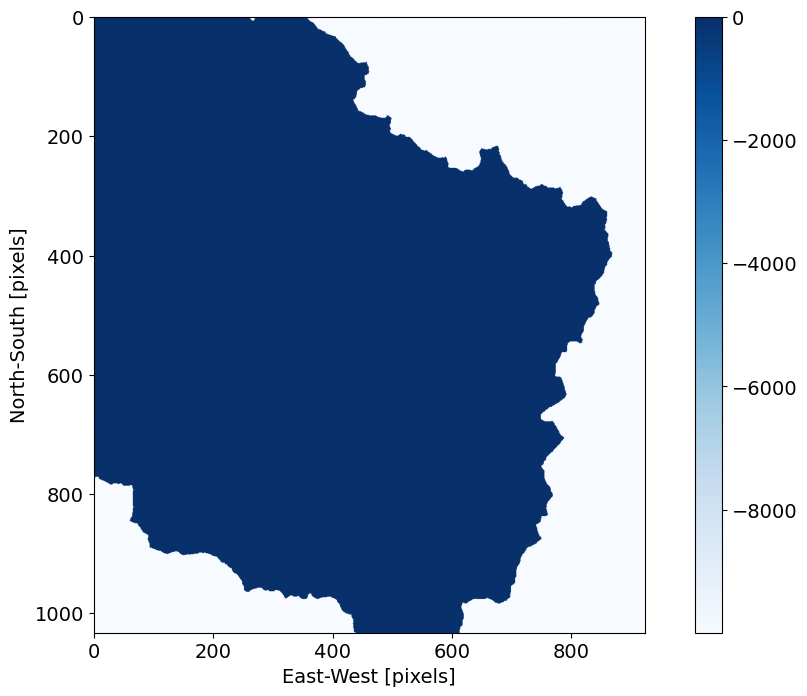

In [4]:
#Check out the SWE raster
fig, ax = plt.subplots(figsize = (14,8))
im = ax.imshow(swe,cmap='Blues')
ax.set_xlabel('East-West [pixels]')
ax.set_ylabel('North-South [pixels]')
divider = make_axes_locatable(ax)  # Place the colorbar outside the main axes
cax = divider.new_horizontal(size = '5%', pad = 0.5, pack_start = False)
fig.add_axes(cax)
fig.colorbar(mappable=im, cax=cax)
plt.show()


Yep, it looks like there are negative (Na) values outside the snowy areas that are at -10,000 m of snow water equivalent. If I mask those then I should be able to see variation within the ROI

In [5]:
#Calcualte DEM stats
zmin = np.nanmin(dem)
zmax = np.nanmax(dem)
zmean = np.nanmean(dem)
zstd = np.nanstd(dem)
print(f"DEM Stats:\n Min: {zmin} m\n Max: {zmax} m\n Mean: {zmean:.2f} m\n Std Dev: {zstd:.2f} m")

DEM Stats:
 Min: 2107.984375 m
 Max: 4337.47119140625 m
 Mean: 3136.18 m
 Std Dev: 359.35 m


[-9.9990000e+03  0.0000000e+00  4.6404947e-09 ...  2.8734846e+00
  3.0506592e+00  3.1331856e+00]


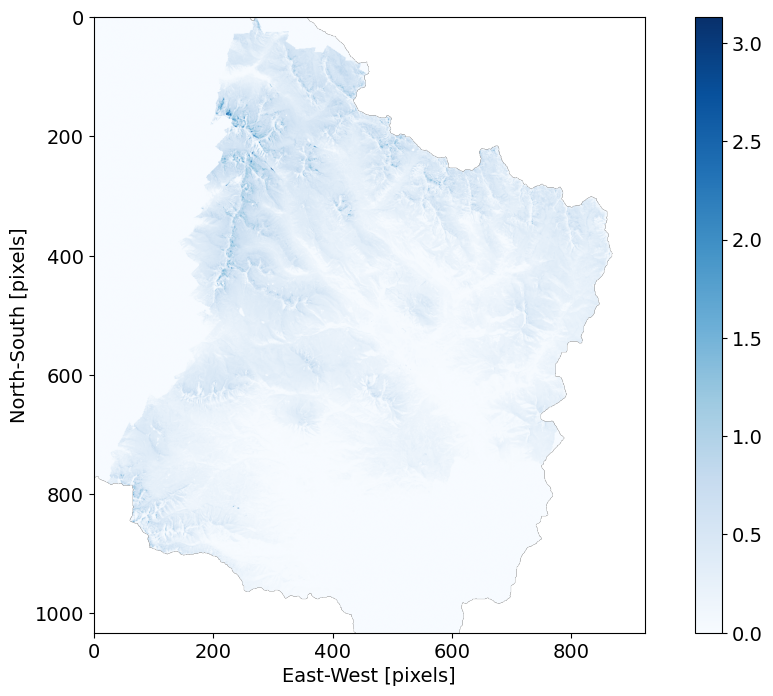

In [6]:
#Check all SWE values to see what the Nan values are
swe_values = np.unique(swe)
print(swe_values)

#Mask out SWE with values of -9999
swe_masked = np.ma.masked_where(swe == -9999, swe)

#Plot the masked SWE data
fig, ax = plt.subplots(figsize = (14,8))
im = ax.imshow(swe_masked,cmap='Blues')
ax.set_xlabel('East-West [pixels]')
ax.set_ylabel('North-South [pixels]')
divider = make_axes_locatable(ax)  # Place the colorbar outside the main axes
cax = divider.new_horizontal(size = '5%', pad = 0.5, pack_start = False)
fig.add_axes(cax)
fig.colorbar(mappable=im, cax=cax)
plt.show()

Okay, this looks a lot more like it!There are large chunks of 0, some true zeros and some fake zeros. I think it makes sense to keep them as we don't want to artificially inflate our SWE averages by getting rid of zeros in the lower elevations. Maybe it's better to think there's less water than there is than expecting more than there is. It's like a nice surprise.

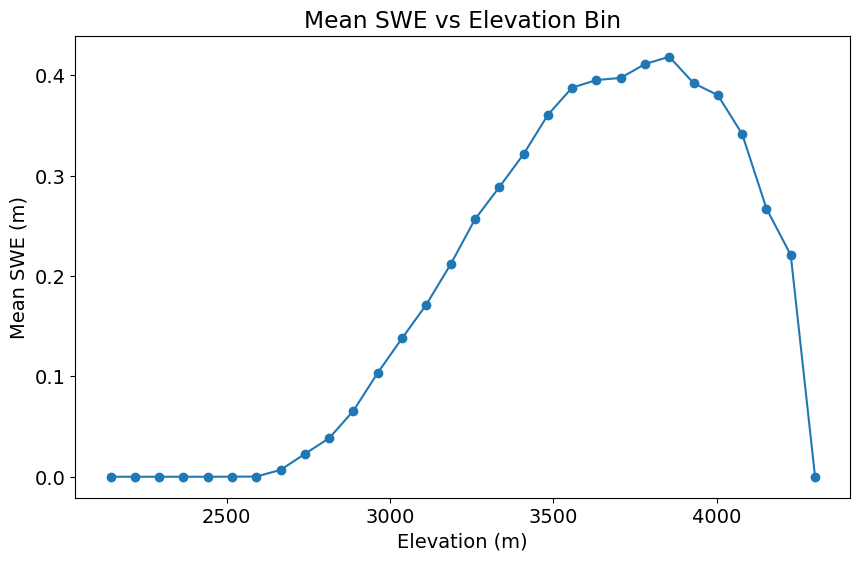

In [7]:
# Bin the elevation data and compute fractional area for each bin
zhist, zbins = np.histogram(dem, bins=30, range=(zmin, zmax))
zbin_center = (zbins[:-1] + zbins[1:])/2
zfrac = zhist/zhist.sum()

#Create a function to mask elevations outside a given range
def z_in_range(dem, zmin, zmax):
    """Mask elevations outside [zmin, zmax] so downstream code works on a focused slice."""
    return np.ma.masked_outside(dem, zmin, zmax)

#Calculate mean SWE per elevation bin
def mean_swe_by_elevation(swe_array, dem_array, zbins):
    mean_swe = np.zeros(len(zbins) - 1)
    
    for i in range(len(zbins) - 1):
        zmask = z_in_range(dem_array, zbins[i], zbins[i+1])
        swe_masked = np.ma.masked_array(swe_array, mask=zmask.mask)  # keep only elevations in this bin
        mean_swe[i] = swe_masked.mean()  # mean over valid pixels
    
    return mean_swe

mean_swe = mean_swe_by_elevation(swe_masked, dem, zbins)

#Calculate standard deviation of SWE per elevation bin
def std_swe_by_elevation(swe_array, dem_array, zbins):
    std_swe = np.zeros(len(zbins) - 1)
    
    for i in range(len(zbins) - 1):
        zmask = z_in_range(dem_array, zbins[i], zbins[i+1])
        swe_masked = np.ma.masked_array(swe_array, mask=zmask.mask)  # keep only elevations in this bin
        std_swe[i] = swe_masked.std()  # std dev over valid pixels
    
    return std_swe
std_swe = std_swe_by_elevation(swe_masked, dem, zbins)

#Plot mean SWE vs elevation bin
fig, ax = plt.subplots(figsize=(10,6))
ax.plot(zbin_center, mean_swe, marker='o')
ax.set_xlabel('Elevation (m)')
ax.set_ylabel('Mean SWE (m)')
ax.set_title('Mean SWE vs Elevation Bin')
plt.show()

This looks pretty good! The high-elevations are wonky probably due to those false zeros that are dragging it down, but the general curve looks right. Low SWE at low elevations and high SWE at high elevations. I experimented a bit with bin size to get a smoother curve.

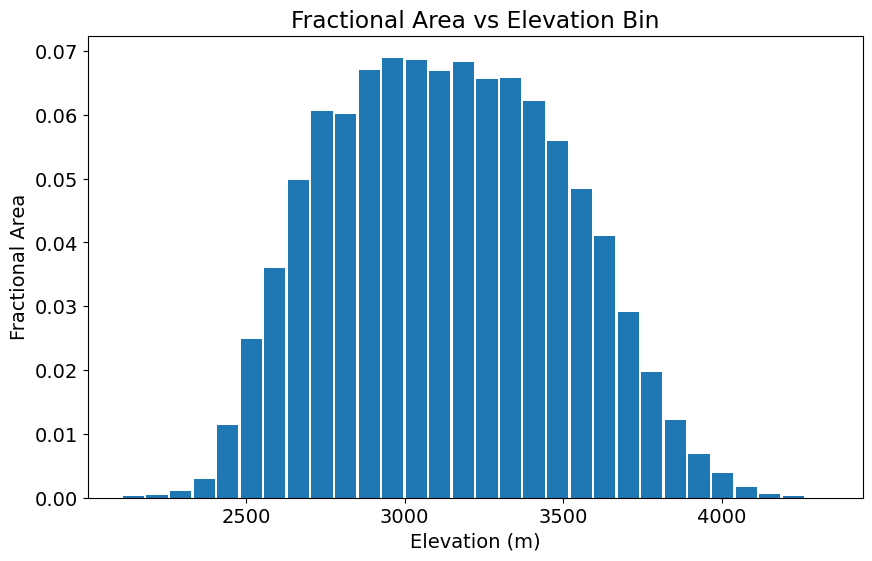

In [8]:
#Plot fractional area vs elevation bin
fig, ax = plt.subplots(figsize=(10,6))
ax.bar(zbin_center, zfrac, width=(zbins[1]-zbins[0])*0.9)
ax.set_xlabel('Elevation (m)')
ax.set_ylabel('Fractional Area')
ax.set_title('Fractional Area vs Elevation Bin')
plt.show()

This looks pretty good too.

In [9]:
#Check pixel size of SWE raster
swe_transform = swe_data.transform
pixel_size_x = swe_transform.a
pixel_size_y = -swe_transform.e  # negative because of the coordinate system
print(f"SWE Pixel Size: {pixel_size_x} m x {pixel_size_y} m")

#examine zhist to make sure it's the right thing to multiply by (counts of pixels in each bin)
print(zhist)

SWE Pixel Size: 50.000101089 m x 50.000101089 m
[  183   467  1030  2771 10835 23801 34404 47554 57796 57355 63988 65810
 65450 63849 65178 62573 62726 59400 53347 46119 39179 27822 18738 11553
  6476  3669  1601   595   192    31]


This looks right, with higher elevations and lower elevations having less counts within their bins. 

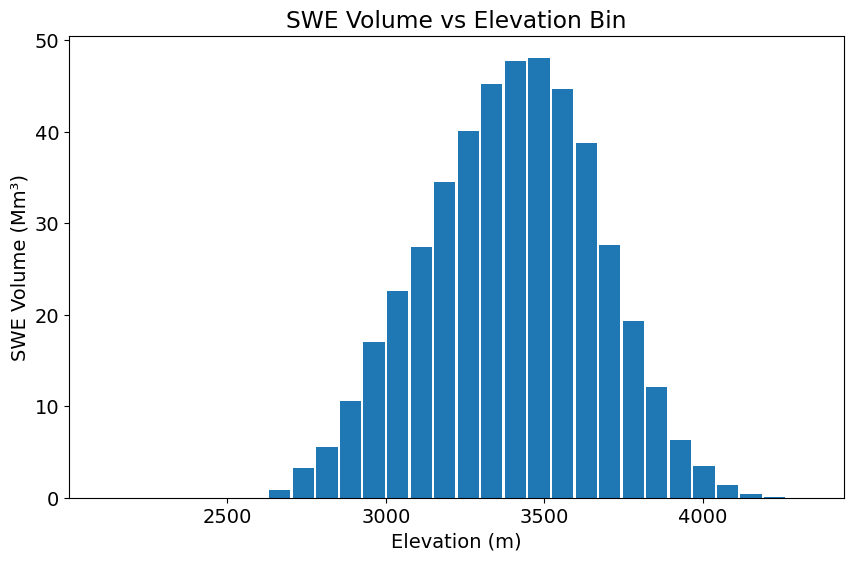

In [10]:


#Plot SWE volume by elevation bin (pixels are 50x50m so area per pixel is 2500 m^2)
swe_volume = (mean_swe * zhist * 2500)/(1000000)  # volume in Mm^3
fig, ax = plt.subplots(figsize=(10,6))
ax.bar(zbin_center, swe_volume, width=(zbins[1]-zbins[0])*0.9)
ax.set_xlabel('Elevation (m)')
ax.set_ylabel('SWE Volume (Mm³)')
ax.set_title('SWE Volume vs Elevation Bin')
plt.show()




This looks good too! I confused myself a bit with what I should multiply by, but I think 50-ish million cubic meters seems about right for the max.

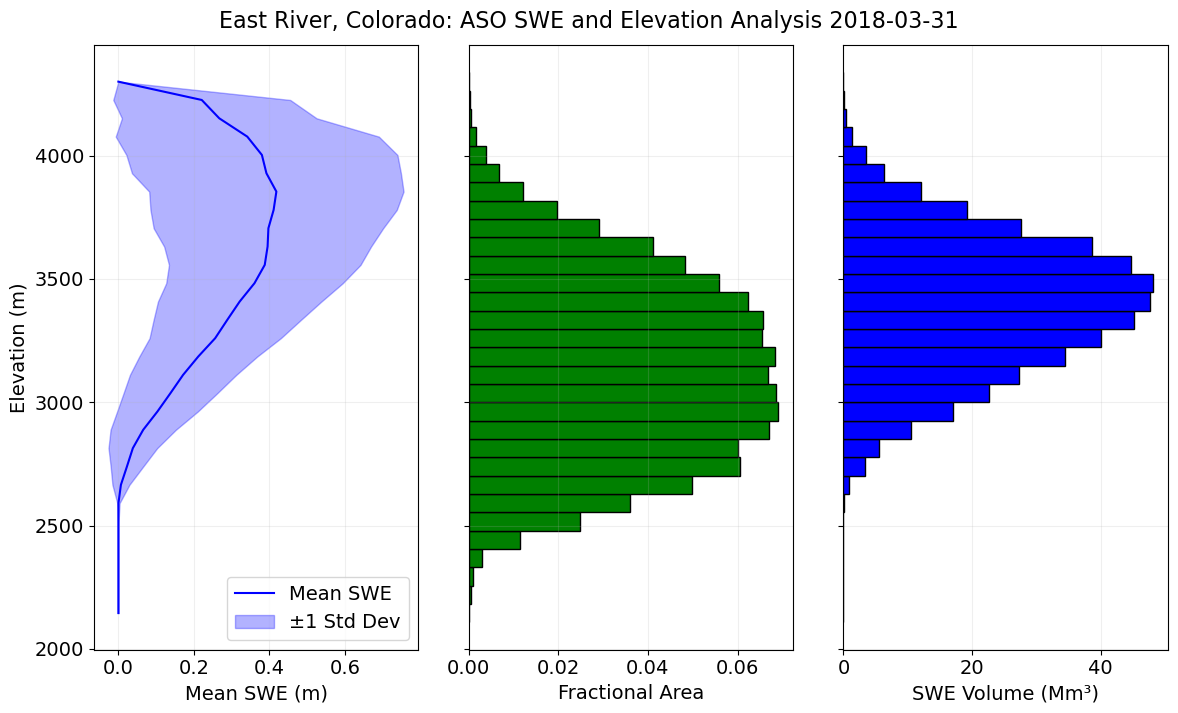

In [11]:
#Create final plot - 3 subplots: mean SWE, fractional area, SWE volume vs elevation bin vertically oriented with subplot_mosaic
# Create vertical subplot mosaic
fig, axes = plt.subplots(1, 3, figsize=(12, 7), sharey=True)  # sharey aligns y-axes

# swe vs elevation
axes[0].grid(True, alpha=0.2, zorder=0)
axes[0].plot(mean_swe, zbin_center, marker=None, color='b',label='Mean SWE')
axes[0].fill_betweenx(zbin_center, mean_swe-std_swe, mean_swe+std_swe, color='b', alpha=0.3, label='±1 Std Dev')
axes[0].set_xlabel('Mean SWE (m)')
axes[0].set_ylabel('Elevation (m)')
axes[0].legend()

# elevation histogram (fractional area)
axes[1].grid(True, alpha=0.2, zorder=0)
axes[1].barh(zbin_center, zfrac, height=np.diff(zbins), color='g', edgecolor='k')
axes[1].set_xlabel('Fractional Area')
axes[1].set_ylabel('')  # shared y-axis


# swe volume vs elevation
axes[2].barh(zbin_center, swe_volume,height=np.diff(zbins), color='b', edgecolor='k',zorder=3)
axes[2].set_xlabel('SWE Volume (Mm³)')
axes[2].set_ylabel('')  # shared y-axis
axes[2].grid(True, alpha=0.2,zorder=0)

plt.tight_layout()
fig.suptitle('East River, Colorado: ASO SWE and Elevation Analysis ' + easy_date, y=1.02, fontsize=16)
plt.show()


Looking good! I tried it for other dates and it worked for them as well. One thing I couldn't figure out is why the fractional area plot grid won't sit nicely behind the bars. I set the zorder and it still won't sit back! April 2019 is the one that didn't look very "normal". It seems like there was an avalanche maybe? The rest of the data seems like it is still good, it's just hard to visualize well with that huge spike. It seems crazy that an avalanche would push that much snow down to low elevations based on its pretty small size, but I am no snow scientist.